## Oppgave 3)

In [157]:
#INITIALISERING

#Impoertering
import numpy as np
from matplotlib import pyplot as plt

params = {
    "alfa"      : 0.8,
    "Tp"        : 500,
    "Nx"        : 100,
    "beta_k"    : 5000   
}
params["L"] = 2*params["Nx"]
params["Np"] = 12*params["Nx"]
params["timeSteps"] = 20*params["Tp"]

In [158]:
#HJELPEFUNKSJONER

#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (Nx-periode)/((1-alfa)*Nx)

def V2(x, params):                          #også uten k for samme grunn
    return 0


#Sannsynlighetsfunksjoner p+ og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1)%L,params)-V((x+1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x+1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner

def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x+1)%L,params)-V((x-1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x-1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


#Look-up tabeller for raskere kjøring
def lookUpTabell_V1(params):
    L = params["L"]

    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V1, params)
        tabell_V1_p_neg[x] = p_neg(x, V1, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]

    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#OPPGAVE 3 FUNKSJONER
def particleCurrent_sim(partiklerPos, params, tabeller):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    startPot_pos_table = tabeller["startPot_pos_table"]
    startPot_neg_table = tabeller["startPot_neg_table"]
    secondPot_pos_table = tabeller["secondPot_pos_table"]
    secondPot_neg_table = tabeller["secondPot_neg_table"]

    particleCurrent = np.zeros(timeSteps)

    for k in range(timeSteps):
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = startPot_pos_table, startPot_neg_table
        else:
            tabell_p_pos, tabell_p_neg = secondPot_pos_table, secondPot_neg_table
        
        randomtabell = np.random.rand(Np)

        posProb = tabell_p_pos[partiklerPos]
        negProb = tabell_p_neg[partiklerPos]

        neg_flytt = (randomtabell <= negProb)
        pos_flytt = (~neg_flytt) & (randomtabell >= (1 - posProb))

        partiklerPos[neg_flytt] -= 1
        partiklerPos[pos_flytt] += 1
        partiklerPos %= L

        # for i in range(len(partiklerPos)):
        #         x = partiklerPos[i]

        #         if randomtabell[i] <= tabell_p_neg[x]:      
        #             x -= 1                                
        #             n_neg += 1                            
        #         elif randomtabell[i] >= (1 - tabell_p_pos[x]):
        #             x += 1
        #             n_pos += 1
        #         partiklerPos[i] = x % (L)

        n_pos = pos_flytt.sum()
        n_neg = neg_flytt.sum()
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

def syklusSnitt(current, params):
    syklus_len = 2*params["Tp"]
    n_cycles = len(current)//syklus_len
    return np.array([current[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

#oppgave 3a hjelpefunksjoner
def init_partikler_3a(params):
    L = params["L"]
    return np.repeat(np.arange(0,L), 6)

#oppgave 3b hjelpefunksjoner
def init_partikler_3b(params):
    Nx = params["Nx"]
    Np = params["Np"]
    return np.repeat([0,Nx], Np//2)

#oppgave 3c hjelpefunksjoner
def init_partikler_3c(params):
    Np = params["Np"]
    return np.zeros(Np, dtype=int)


Oppgave 3a)

In [ ]:
def oppgave_3a(params):
    lokal_params = params.copy()
    partiklerPos = init_partikler_3a(params = lokal_params)

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3a = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3a)
    
    particleCurrent_syklusSnitt = syklusSnitt(particleCurrent, params = lokal_params)

    return particleCurrent_syklusSnitt


particleCurrent_3a = oppgave_3a(params)
print(particleCurrent_3a)

[-0.03025    -0.013      -0.01225    -0.01291667 -0.01341667 -0.01291667
 -0.01375    -0.01375    -0.01175    -0.01233333]


Oppgave 3b)

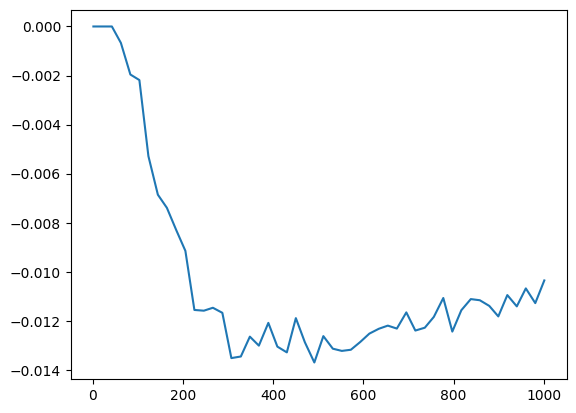

In [201]:
def oppgave_3b(params):
    #parameteroppdatering for 3b, (lager lokal for å ikke endre globale params)
    lokal_params = params.copy()
    lokal_params["Np"] = 40*lokal_params["Nx"]

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3b = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(1, 1001, 50)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3b)

        resultatarray[i] = particleCurrent.mean()

    return Tp_array, resultatarray

Tp_array, particleCurrent_3b = oppgave_3b(params)
#print(particleCurrent_3b)
plt.plot(Tp_array, particleCurrent_3b)
plt.show()

Oppgave 3c)

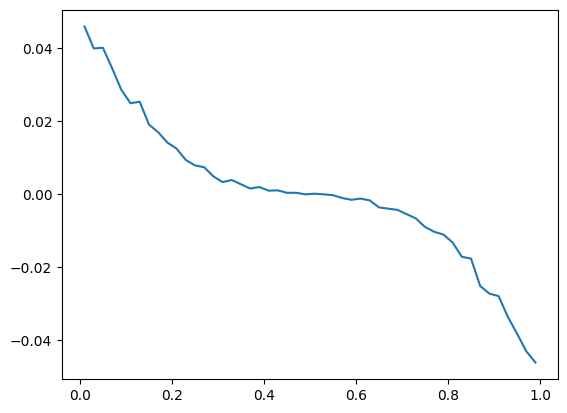

In [202]:
def oppgave_3c(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    resultatarray = np.zeros(len(alfa_array))

    for i in range(len(alfa_array)):
        lokal_params["alfa"] = alfa_array[i]
        partiklerPos = init_partikler_3c(params = lokal_params)

        tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
        tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

        tabeller_potensial_3c = {
            "startPot_pos_table" : tabell_V2_p_pos,
            "startPot_neg_table" : tabell_V2_p_neg,
            "secondPot_pos_table": tabell_V1_p_pos,
            "secondPot_neg_table": tabell_V1_p_neg
        }
        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3c)
        resultatarray[i] = particleCurrent.mean()
    
    return alfa_array, resultatarray


alfa_array, particleCurrent_3c = oppgave_3c(params)
#print(particleCurrent_3b)
plt.plot(alfa_array, particleCurrent_3c)
plt.show()    

Oppgave 3d)

In [ ]:
#oppgave 3d